#  Pediatric Genetic Disorder Prediction
## Complete Data Preprocessing Pipeline

> **Goal:** Predict both `Genetic Disorder` (3 classes) and `Disorder Subclass` (9 classes) from heterogeneous clinical/demographic features.

---
### Pipeline Overview
1. Environment Setup
2. Load & Inspect Data
3. Drop Irrelevant Features
4. Handle Missing Values
5. Fix Data Types & Encoding
6. Outlier Detection & Treatment
7. Feature Engineering
8. Encode Categorical Features
9. Handle Class Imbalance
10. Feature Selection
11. Final Sanity Check & Save


---
## 1. Environment Setup

In [ ]:
!pip install -q imbalanced-learn category_encoders

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import category_encoders as ce

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

print('Libraries loaded successfully')

✅ Libraries loaded successfully


---
## 2. Load & Inspect Data

In [ ]:
train = pd.read_csv('/kaggle/input/datasets/masteranany/newgec/train.csv')
test  = pd.read_csv('/kaggle/input/datasets/masteranany/newgec/test.csv')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
train.head(3)

Train shape : (22083, 45)
Test  shape : (9465, 43)


,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,Mother's age,Father's age,Institute Name,Location of Institute,Status,Respiratory Rate (breaths/min),Heart Rate (rates/min,Test 1,Test 2,Test 3,Test 4,Test 5,Parental consent,Follow-up,Gender,Birth asphyxia,Autopsy shows birth defect (if applicable),Place of birth,Folic acid details (peri-conceptional),H/O serious maternal illness,H/O radiation exposure (x-ray),H/O substance abuse,Assisted conception IVF/ART,History of anomalies in previous pregnancies,No. of previous abortion,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,NaN,NaN,Boston Specialty & Rehabilitation Hospital,"55 FRUIT ST\nCENTRAL, MA 02114\n(42.3624748574...",Alive,Normal (30-60),Normal,0.0,NaN,NaN,1.0,0.0,Yes,High,NaN,NaN,Not applicable,Institute,No,NaN,No,No,No,Yes,NaN,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,NaN,23.0,St. Margaret's Hospital For Women,"1515 COMMONWEALTH AV\nALLSTON/BRIGHTON, MA 021...",Deceased,Tachypnea,Normal,NaN,0.0,0.0,1.0,0.0,Yes,High,NaN,No,NaN,NaN,Yes,Yes,Not applicable,Not applicable,No,Yes,NaN,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,41.0,22.0,NaN,-,Alive,Normal (30-60),Tachycardia,0.0,0.0,0.0,1.0,0.0,Yes,Low,NaN,No record,Not applicable,NaN,Yes,No,Yes,NaN,Yes,Yes,4.0,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22083 entries, 0 to 22082
Data columns (total 45 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Patient Id                                        22083 non-null  object 
 1   Patient Age                                       20656 non-null  float64
 2   Genes in mother's side                            22083 non-null  object 
 3   Inherited from father                             21777 non-null  object 
 4   Maternal gene                                     19273 non-null  object 
 5   Paternal gene                                     22083 non-null  object 
 6   Blood cell count (mcL)                            22083 non-null  float64
 7   Patient First Name                                22083 non-null  object 
 8   Family Name                                       12392 non-null  object 
 9   Father's name    

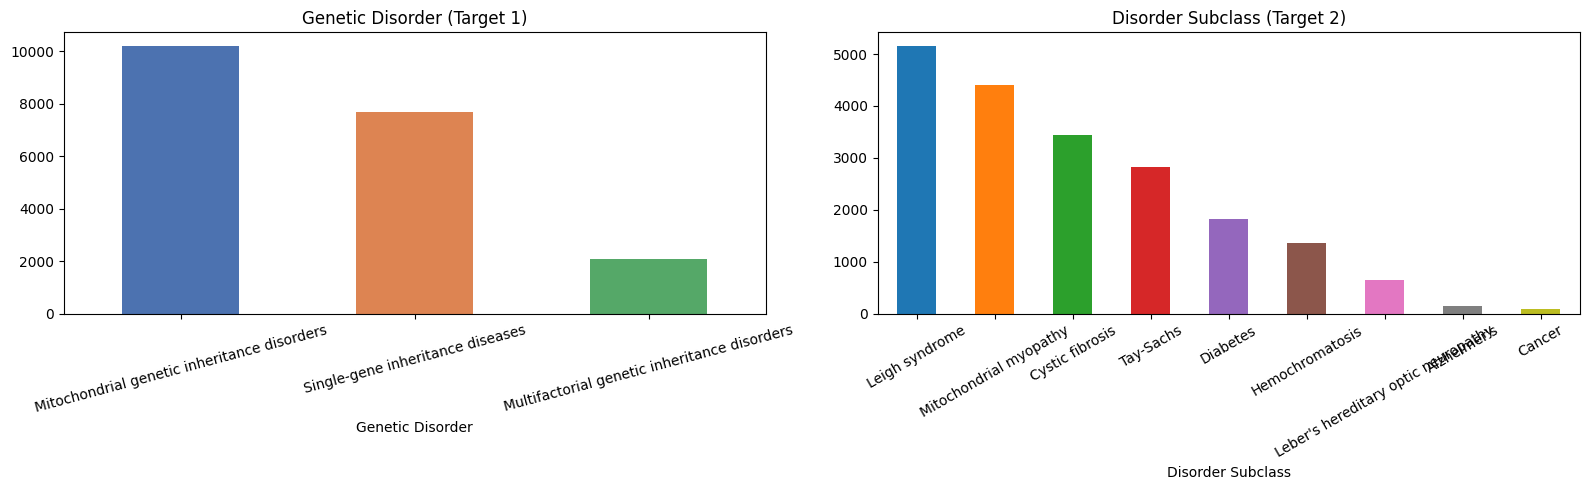


--- Genetic Disorder counts ---
Genetic Disorder
Mitochondrial genetic inheritance disorders     10202
Single-gene inheritance diseases                 7664
Multifactorial genetic inheritance disorders     2071
Name: count, dtype: int64

--- Disorder Subclass counts ---
Disorder Subclass
Leigh syndrome                         5160
Mitochondrial myopathy                 4405
Cystic fibrosis                        3448
Tay-Sachs                              2833
Diabetes                               1817
Hemochromatosis                        1355
Leber's hereditary optic neuropathy     648
Alzheimer's                             152
Cancer                                   97
Name: count, dtype: int64


In [ ]:
#Target distribution 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

train['Genetic Disorder'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'],
    title='Genetic Disorder (Target 1)', rot=15)

train['Disorder Subclass'].value_counts().plot(
    kind='bar', ax=axes[1], color=sns.color_palette('tab10', 9),
    title='Disorder Subclass (Target 2)', rot=30)

plt.tight_layout()
plt.show()

print('\n--- Genetic Disorder counts ---')
print(train['Genetic Disorder'].value_counts())
print('\n--- Disorder Subclass counts ---')
print(train['Disorder Subclass'].value_counts())

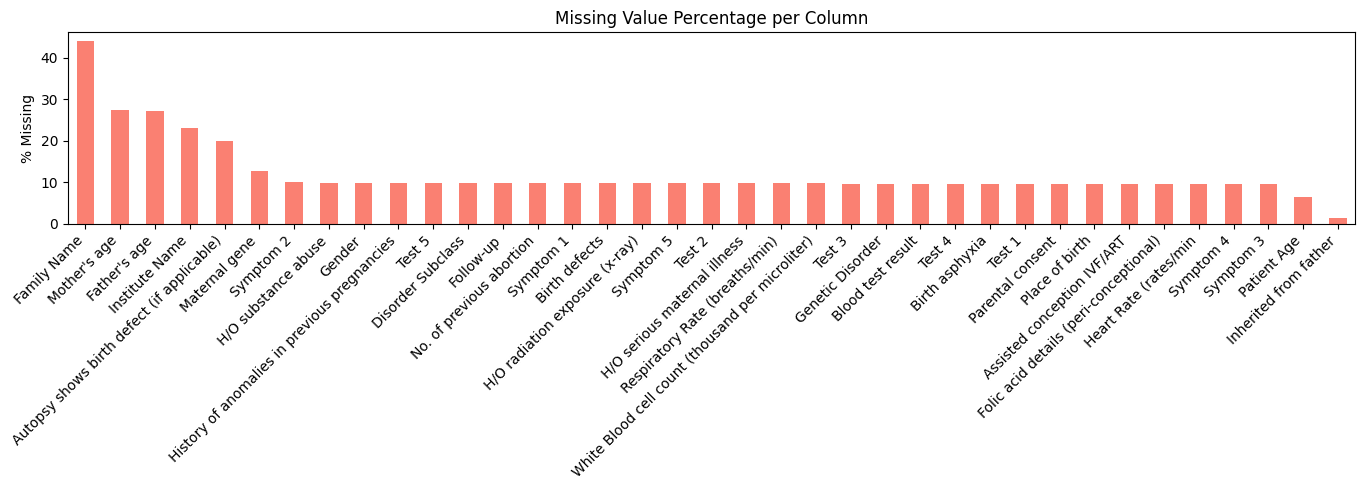

Family Name                                         43.884436
Mother's age                                        27.333243
Father's age                                        27.106824
Institute Name                                      23.121858
Autopsy shows birth defect (if applicable)          19.888602
Maternal gene                                       12.724720
Symptom 2                                           10.062039
H/O substance abuse                                  9.939773
Gender                                               9.840149
History of anomalies in previous pregnancies         9.835620
Test 5                                               9.826563
Disorder Subclass                                    9.817507
Follow-up                                            9.808450
No. of previous abortion                             9.790336
Symptom 1                                            9.758638
Birth defects                                        9.754109
H/O radi

In [ ]:
#  Missing value heatmap 
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(14, 5))
missing.plot(kind='bar', color='salmon')
plt.title('Missing Value Percentage per Column')
plt.ylabel('% Missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(missing.to_string())

---
## 3. Drop Irrelevant / High-Cardinality Features

These columns carry **no predictive signal** for genetic disorders:
- `Patient Id` — identifier only
- `Patient First Name`, `Family Name`, `Father's name` — free-text names
- `Institute Name`, `Location of Institute` — administrative metadata
- `Place of birth` — high cardinality geographic noise

In [16]:
COLS_TO_DROP = [
    'Patient Id',
    'Patient First Name',
    'Family Name',
    "Father's name",
    'Institute Name',
    'Location of Institute',
    'Place of birth',
]

# Keep Patient Id in test for submission
test_ids = test['Patient Id'].copy()

train.drop(columns=COLS_TO_DROP, inplace=True, errors='ignore')
test.drop(columns=COLS_TO_DROP,  inplace=True, errors='ignore')

print(f'Train shape after drop: {train.shape}')
print(f'Test  shape after drop: {test.shape}')

Train shape after drop: (22083, 38)
Test  shape after drop: (9465, 36)


In [19]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22083 entries, 0 to 22082
Data columns (total 36 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Patient Age                                       20656 non-null  float64
 1   Genes in mother's side                            22083 non-null  object 
 2   Inherited from father                             21777 non-null  object 
 3   Maternal gene                                     19273 non-null  object 
 4   Paternal gene                                     22083 non-null  object 
 5   Blood cell count (mcL)                            22083 non-null  float64
 6   Mother's age                                      16047 non-null  float64
 7   Father's age                                      16097 non-null  float64
 8   Status                                            22083 non-null  object 
 9   Respiratory Rate 

---
## 4. Separate Targets & Combine Train+Test for Unified Preprocessing

In [18]:
TARGET1 = 'Genetic Disorder'
TARGET2 = 'Disorder Subclass'

y1 = train[TARGET1].copy()
y2 = train[TARGET2].copy()

train.drop(columns=[TARGET1, TARGET2], inplace=True)

# Combine for unified preprocessing (avoids train/test skew)
n_train = len(train)
combined = pd.concat([train, test], axis=0, ignore_index=True)

print(f'Combined shape: {combined.shape}  |  n_train={n_train}')

KeyError: 'Genetic Disorder'

In [22]:
y2.head()

0    Leber's hereditary optic neuropathy
1                        Cystic fibrosis
2                               Diabetes
3                         Leigh syndrome
4                                 Cancer
Name: Disorder Subclass, dtype: object

---
## 5. Fix Data Types

Several columns need explicit type casting before imputation or encoding.

In [ ]:
# Columns expected to be numeric 
NUMERIC_COLS = [
    'Patient Age',
    'Blood cell count (mcL)',
    "Mother's age",
    "Father's age",
    'Respiratory Rate (breaths/min)',
    'Heart Rate (rates/min',   # note: trailing space/bracket in raw data
    'Test 1', 'Test 2', 'Test 3', 'Test 4', 'Test 5',
    'No. of previous abortion',
    'White Blood cell count (thousand per microliter)',
]

#  Binary / ordinal categorical 
BINARY_COLS = [
    'Genes in mother\'s side',
    'Inherited from father',
    'Maternal gene',
    'Paternal gene',
    'Status',
    'Parental consent',
    'Follow-up',
    'Gender',
    'Birth asphyxia',
    'Autopsy shows birth defect (if applicable)',
    'Folic acid details (peri-conceptional)',
    'H/O serious maternal illness',
    'H/O radiation exposure (x-ray)',
    'H/O substance abuse',
    'Assisted conception IVF/ART',
    'History of anomalies in previous pregnancies',
    'Birth defects',
    'Blood test result',
    'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5',
]

# Coerce numeric columns (handles stray strings → NaN)
for col in NUMERIC_COLS:
    if col in combined.columns:
        combined[col] = pd.to_numeric(combined[col], errors='coerce')

# Strip whitespace from categorical columns
for col in combined.select_dtypes('object').columns:
    combined[col] = combined[col].str.strip()

print(' Data types fixed')
combined.dtypes.value_counts()

✅ Data types fixed


float64    18
object     18
Name: count, dtype: int64

---
## 6. Handle Missing Values

### Strategy:
| Column Type | Missing % | Strategy |
|---|---|---|
| Numeric continuous | < 20% | **Median** imputation |
| Numeric continuous | ≥ 20% | **KNN** imputation (k=5) |
| Categorical binary | any | **Mode** imputation |
| Categorical multi | any | **'Unknown'** fill |

> For high-stakes medical data, KNN imputation is preferred for continuous vitals since it preserves local correlations.

In [ ]:
#  Split numeric vs categorical for separate imputation 
num_cols = combined.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = combined.select_dtypes(include='object').columns.tolist()

print(f'Numeric cols  : {len(num_cols)}')
print(f'Categorical cols: {len(cat_cols)}')

# Check missing % per numeric column
num_missing_pct = (combined[num_cols].isnull().sum() / len(combined) * 100)
high_missing_num = num_missing_pct[num_missing_pct >= 20].index.tolist()
low_missing_num  = num_missing_pct[(num_missing_pct > 0) & (num_missing_pct < 20)].index.tolist()

print(f'\nHigh missing numeric (KNN): {high_missing_num}')
print(f'Low  missing numeric (Median): {low_missing_num}')

Numeric cols  : 18
Categorical cols: 18

High missing numeric (KNN): ['Respiratory Rate (breaths/min)', 'Heart Rate (rates/min']
Low  missing numeric (Median): ['Patient Age', "Mother's age", "Father's age", 'Test 1', 'Test 2', 'Test 3', 'Test 4', 'Test 5', 'No. of previous abortion', 'White Blood cell count (thousand per microliter)', 'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']


In [ ]:
#  Median imputation for low-missing numeric columns 
if low_missing_num:
    med_imputer = SimpleImputer(strategy='median')
    combined[low_missing_num] = med_imputer.fit_transform(combined[low_missing_num])
    print(f'✅ Median imputed: {low_missing_num}')

#  KNN imputation for high-missing numeric columns 
if high_missing_num:
    knn_imputer = KNNImputer(n_neighbors=5)
    combined[high_missing_num] = knn_imputer.fit_transform(combined[high_missing_num])
    print(f'✅ KNN imputed   : {high_missing_num}')

#  Mode imputation for categorical columns 
for col in cat_cols:
    if combined[col].isnull().sum() > 0:
        mode_val = combined[col].mode()
        if len(mode_val) > 0:
            combined[col].fillna(mode_val[0], inplace=True)
        else:
            combined[col].fillna('Unknown', inplace=True)

# Final check
remaining_null = combined.isnull().sum().sum()
print(f'\n Total remaining nulls: {remaining_null}')

✅ Median imputed: ['Patient Age', "Mother's age", "Father's age", 'Test 1', 'Test 2', 'Test 3', 'Test 4', 'Test 5', 'No. of previous abortion', 'White Blood cell count (thousand per microliter)', 'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']
✅ KNN imputed   : ['Respiratory Rate (breaths/min)', 'Heart Rate (rates/min']

✅ Total remaining nulls: 0


---
## 7. Outlier Detection & Treatment

Use **IQR capping** (Winsorization) for medical vitals — we don't remove rows because every patient record is valuable, but extreme values are clipped to [Q1 - 1.5×IQR, Q3 + 1.5×IQR].

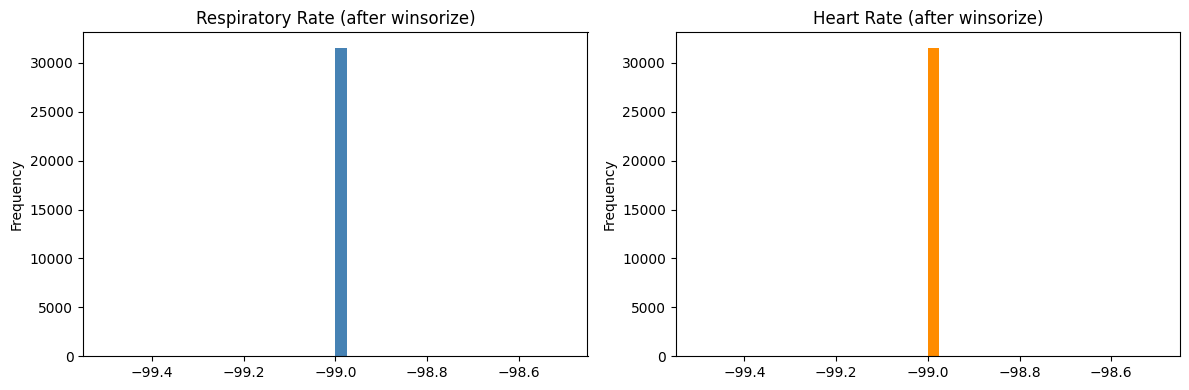

✅ Outlier capping done


In [26]:
# Columns to winsorize (only meaningful continuous vitals)
WINSORIZE_COLS = [
    'Patient Age',
    'Blood cell count (mcL)',
    "Mother's age",
    "Father's age",
    'Respiratory Rate (breaths/min)',
    'Heart Rate (rates/min',
    'White Blood cell count (thousand per microliter)',
]

def winsorize_iqr(df, cols, factor=1.5):
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        df[col] = df[col].clip(lower, upper)
    return df

combined = winsorize_iqr(combined, WINSORIZE_COLS)

# Visual check on one key vital
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
combined['Respiratory Rate (breaths/min)'].plot(kind='hist', bins=40,
    ax=axes[0], title='Respiratory Rate (after winsorize)', color='steelblue')
combined['Heart Rate (rates/min'].plot(kind='hist', bins=40,
    ax=axes[1], title='Heart Rate (after winsorize)', color='darkorange')
plt.tight_layout(); plt.show()

print('✅ Outlier capping done')

---
## 8. Feature Engineering

Creating domain-meaningful derived features to improve signal for genetic disorder classification.

In [ ]:
#  8.1 Parental Age Features 
combined['parental_age_sum']  = combined["Mother's age"] + combined["Father's age"]
combined['parental_age_diff'] = (combined["Father's age"] - combined["Mother's age"]).abs()
combined['mother_age_risk']   = (combined["Mother's age"] >= 35).astype(int)  # AMA flag
combined['father_age_risk']   = (combined["Father's age"] >= 40).astype(int)  # advanced paternal age

#  8.2 Genetic Inheritance Risk Score 
# Sum of binary gene flags (each = 1 if gene mutation present)
gene_cols = ['Genes in mother\'s side', 'Inherited from father',
             'Maternal gene', 'Paternal gene']
for col in gene_cols:
    if col in combined.columns:
        combined[col + '_bin'] = (combined[col].str.lower() == 'yes').astype(int)

bin_gene_cols = [c for c in combined.columns if c.endswith('_bin')]
combined['genetic_risk_score'] = combined[bin_gene_cols].sum(axis=1)

#  8.3 Symptom Burden Score 
symptom_cols = ['Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']
for col in symptom_cols:
    if col in combined.columns:
        combined[col + '_bin'] = (combined[col].astype(str).str.lower().isin(['1', 'yes', 'true'])).astype(int)

symp_bin_cols = [c for c in combined.columns if 'Symptom' in c and c.endswith('_bin')]
combined['symptom_count'] = combined[symp_bin_cols].sum(axis=1)

#  8.4 Prenatal Risk Score 
prenatal_cols = [
    'H/O serious maternal illness',
    'H/O radiation exposure (x-ray)',
    'H/O substance abuse',
    'Assisted conception IVF/ART',
    'History of anomalies in previous pregnancies',
]
for col in prenatal_cols:
    if col in combined.columns:
        combined[col + '_bin'] = (combined[col].str.lower().isin(['yes', '1'])).astype(int)

prenatal_bin_cols = [c for c in combined.columns if any(p in c for p in prenatal_cols) and c.endswith('_bin')]
combined['prenatal_risk_score'] = combined[prenatal_bin_cols].sum(axis=1)

#    8.5 Vital Signs Interaction 
if 'Respiratory Rate (breaths/min)' in combined.columns and 'Heart Rate (rates/min' in combined.columns:
    combined['hr_rr_ratio'] = (
        combined['Heart Rate (rates/min'] / (combined['Respiratory Rate (breaths/min)'] + 1e-5)
    )

#  8.6 Test Score Aggregates 
test_cols = ['Test 1', 'Test 2', 'Test 3', 'Test 4', 'Test 5']
existing_test_cols = [c for c in test_cols if c in combined.columns]
if existing_test_cols:
    combined['test_score_mean'] = combined[existing_test_cols].mean(axis=1)
    combined['test_score_std']  = combined[existing_test_cols].std(axis=1).fillna(0)
    combined['test_score_max']  = combined[existing_test_cols].max(axis=1)

#  8.7 Previous Abortions Risk 
if 'No. of previous abortion' in combined.columns:
    combined['has_prev_abortion'] = (combined['No. of previous abortion'] > 0).astype(int)

print(f' Feature engineering done — new shape: {combined.shape}')

✅ Feature engineering done — new shape: (31548, 62)


---
## 9. Encode Categorical Features

### Strategy:
| Column Type | Encoding |
|---|---|
| Binary Yes/No | Manual 0/1 map |
| Low cardinality (< 10 unique) | Label Encoding |
| High cardinality (≥ 10 unique) | Target Encoding (train only) or frequency encoding |

In [ ]:
#  9.1 Manual binary maps for well-known yes/no columns 
yes_no_cols = [
    'Genes in mother\'s side',
    'Inherited from father',
    'Maternal gene',
    'Paternal gene',
    'Status',
    'Parental consent',
    'H/O serious maternal illness',
    'H/O radiation exposure (x-ray)',
    'H/O substance abuse',
    'Assisted conception IVF/ART',
    'History of anomalies in previous pregnancies',
    'Folic acid details (peri-conceptional)',
    'Birth asphyxia',
]

yn_map = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, '1': 1, '0': 0}

for col in yes_no_cols:
    if col in combined.columns:
        combined[col] = combined[col].map(yn_map).fillna(0).astype(int)

# Gender encoding
if 'Gender' in combined.columns:
    gender_map = {'Male': 1, 'Female': 0, 'Ambiguous': 2, 'male': 1, 'female': 0}
    combined['Gender'] = combined['Gender'].map(gender_map).fillna(2).astype(int)

print('Binary columns encoded')

✅ Binary columns encoded


In [ ]:
#  9.2 Label encode remaining object columns 
remaining_cat = combined.select_dtypes(include='object').columns.tolist()
print(f'Remaining categorical cols to encode: {remaining_cat}')

label_encoders = {}
for col in remaining_cat:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {le.classes_[:5]}...')

print(f'\n All categoricals encoded. Combined shape: {combined.shape}')

Remaining categorical cols to encode: ['Follow-up', 'Autopsy shows birth defect (if applicable)', 'Birth defects', 'Blood test result']
  Follow-up: ['-99' 'High' 'Low']...
  Autopsy shows birth defect (if applicable): ['-99' 'No' 'Not applicable' 'Yes']...
  Birth defects: ['-99' 'Multiple' 'Singular']...
  Blood test result: ['-99' 'abnormal' 'inconclusive' 'normal' 'slightly abnormal']...

✅ All categoricals encoded. Combined shape: (31548, 62)


In [ ]:
#  9.3 Encode targets 
le_t1 = LabelEncoder()
le_t2 = LabelEncoder()

y1_enc = le_t1.fit_transform(y1)
y2_enc = le_t2.fit_transform(y2)

print('Genetic Disorder classes  :', list(le_t1.classes_))
print('Disorder Subclass classes :', list(le_t2.classes_))

Genetic Disorder classes  : ['Mitochondrial genetic inheritance disorders', 'Multifactorial genetic inheritance disorders', 'Single-gene inheritance diseases', nan]
Disorder Subclass classes : ["Alzheimer's", 'Cancer', 'Cystic fibrosis', 'Diabetes', 'Hemochromatosis', "Leber's hereditary optic neuropathy", 'Leigh syndrome', 'Mitochondrial myopathy', 'Tay-Sachs', nan]


---
## 10. Split Back to Train / Test

In [31]:
X_train = combined.iloc[:n_train].copy().reset_index(drop=True)
X_test  = combined.iloc[n_train:].copy().reset_index(drop=True)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y1      : {y1_enc.shape}  | y2: {y2_enc.shape}')

X_train : (22083, 62)
X_test  : (9465, 62)
y1      : (22083,)  | y2: (22083,)


---
## 11. Handle Class Imbalance with SMOTE

We use **SMOTETomek** (SMOTE oversampling + Tomek link cleaning) which both balances classes and removes borderline noisy samples.



In [ ]:
#  Class distribution BEFORE 
print(' Before SMOTE ')
unique, counts = np.unique(y1_enc, return_counts=True)
for u, c in zip(le_t1.classes_, counts):
    print(f'  {u}: {c}')


smt = SMOTETomek(random_state=42)
X_train_bal, y1_bal = smt.fit_resample(X_train, y1_enc)

from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1).fit(X_train)
_, orig_idx = nn.kneighbors(X_train_bal)
y2_bal = y2_enc[orig_idx.flatten()]

print('\n After SMOTETomek ')
unique, counts = np.unique(y1_bal, return_counts=True)
for u, c in zip(le_t1.classes_, counts):
    print(f'  {u}: {c}')

print(f'\nX_train_bal shape: {X_train_bal.shape}')

=== Before SMOTE ===
  Mitochondrial genetic inheritance disorders: 10202
  Multifactorial genetic inheritance disorders: 2071
  Single-gene inheritance diseases: 7664
  nan: 2146

=== After SMOTETomek ===
  Mitochondrial genetic inheritance disorders: 9541
  Multifactorial genetic inheritance disorders: 10194
  Single-gene inheritance diseases: 9547
  nan: 10192

X_train_bal shape: (39474, 62)


---
## 12. Feature Selection

Use **Mutual Information** to rank feature importance and drop near-zero signal features. This reduces noise and improves generalization.

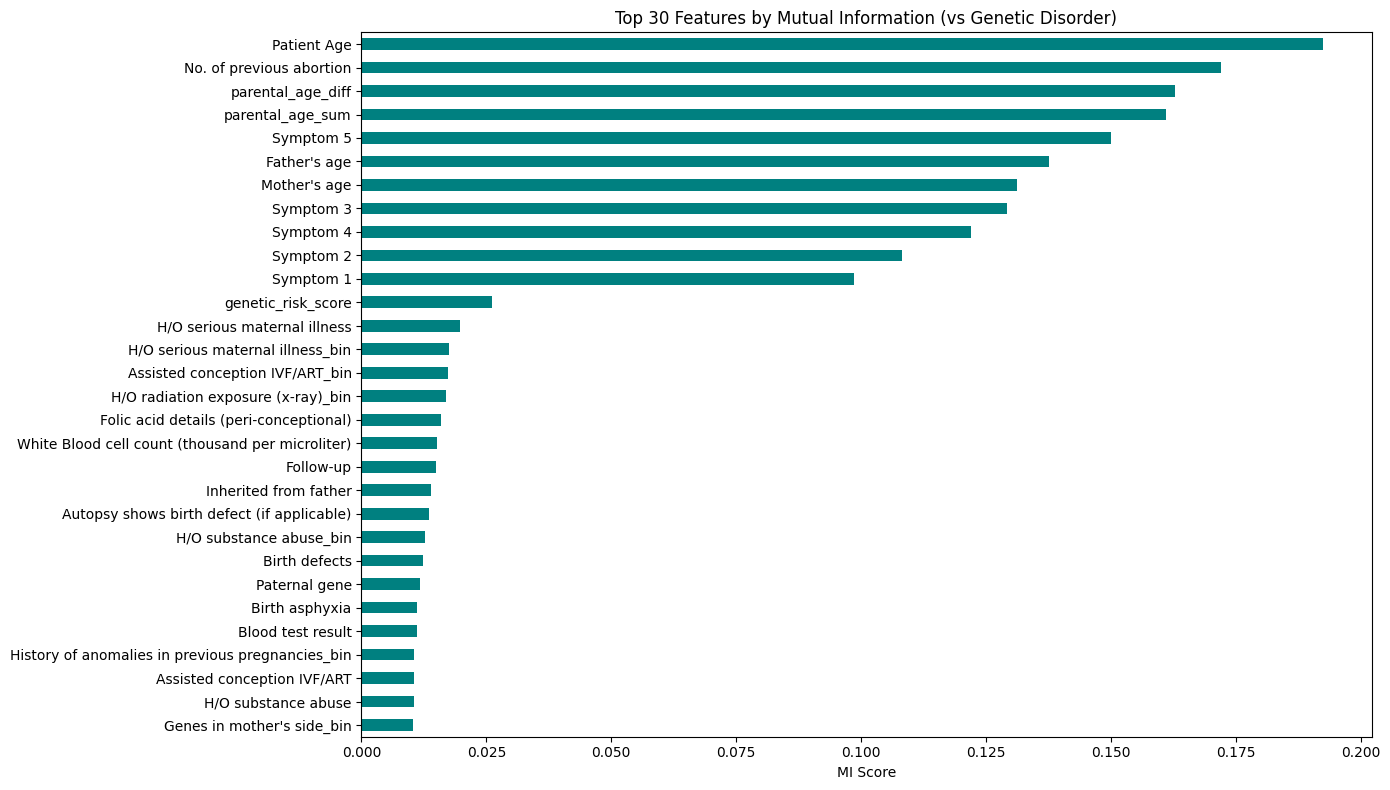


Bottom 10 features (lowest MI):
Respiratory Rate (breaths/min)    0.001019
Parental consent                  0.000895
Symptom 3_bin                     0.000614
Symptom 5_bin                     0.000527
Maternal gene_bin                 0.000494
hr_rr_ratio                       0.000368
Status                            0.000000
Symptom 1_bin                     0.000000
symptom_count                     0.000000
Symptom 2_bin                     0.000000
dtype: float64


In [ ]:
#  Mutual Information Scores (for Target 1) 
mi_scores = mutual_info_classif(X_train_bal, y1_bal, random_state=42)
mi_df = pd.Series(mi_scores, index=X_train_bal.columns).sort_values(ascending=False)

plt.figure(figsize=(14, 8))
mi_df.head(30).plot(kind='barh', color='teal')
plt.title('Top 30 Features by Mutual Information (vs Genetic Disorder)')
plt.xlabel('MI Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nBottom 10 features (lowest MI):')
print(mi_df.tail(10))

In [ ]:
#  Drop near-zero MI features (threshold = 0.001) 
MI_THRESHOLD = 0.001
keep_features = mi_df[mi_df >= MI_THRESHOLD].index.tolist()
drop_features = mi_df[mi_df < MI_THRESHOLD].index.tolist()

print(f'Keeping {len(keep_features)} features, dropping {len(drop_features)}')
if drop_features:
    print(f'Dropped: {drop_features}')

X_train_final = X_train_bal[keep_features].copy()
X_test_final  = X_test[keep_features].copy()

print(f'\nFinal X_train shape: {X_train_final.shape}')
print(f'Final X_test  shape: {X_test_final.shape}')

Keeping 53 features, dropping 9
Dropped: ['Parental consent', 'Symptom 3_bin', 'Symptom 5_bin', 'Maternal gene_bin', 'hr_rr_ratio', 'Status', 'Symptom 1_bin', 'symptom_count', 'Symptom 2_bin']

Final X_train shape: (39474, 53)
Final X_test  shape: (9465, 53)


---
## 13. Correlation Heatmap (Top Features)

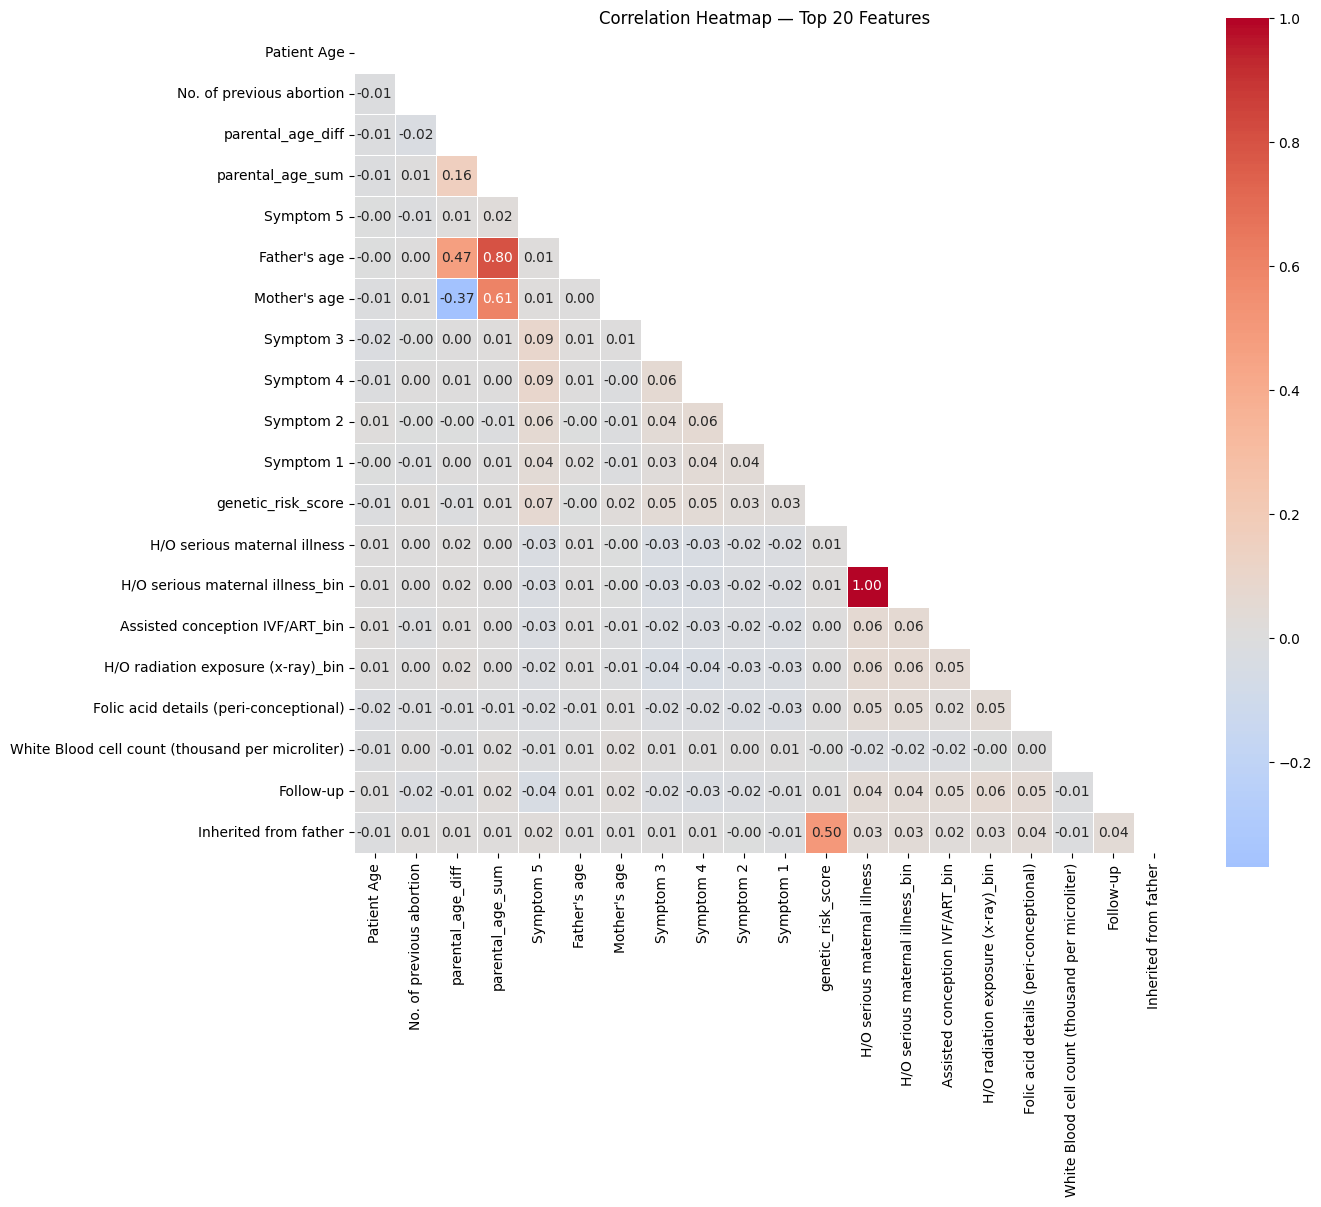

In [35]:
top20 = mi_df.head(20).index.tolist()
corr  = X_train_final[top20].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Top 20 Features')
plt.tight_layout()
plt.show()

---
## 15. Save Preprocessed Data

In [ ]:
# Save preprocessed files
X_train_final.to_csv('X_train_preprocessed.csv', index=False)
X_test_final.to_csv('X_test_preprocessed.csv',   index=False)

np.save('y1_train.npy', y1_bal)
np.save('y2_train.npy', y2_bal)

# Save label encoder mappings for submission decoding
import pickle
with open('le_t1.pkl', 'wb') as f: pickle.dump(le_t1, f)
with open('le_t2.pkl', 'wb') as f: pickle.dump(le_t2, f)
with open('keep_features.pkl', 'wb') as f: pickle.dump(keep_features, f)

print('All preprocessed files saved!')
print()
print('Files saved:')
print('  X_train_preprocessed.csv')
print('  X_test_preprocessed.csv')
print('  y1_train.npy  (Genetic Disorder encoded)')
print('  y2_train.npy  (Disorder Subclass encoded)')
print('  le_t1.pkl     (LabelEncoder for Target 1)')
print('  le_t2.pkl     (LabelEncoder for Target 2)')
print('  keep_features.pkl  (selected feature list)')

✅ All preprocessed files saved!

Files saved:
  X_train_preprocessed.csv
  X_test_preprocessed.csv
  y1_train.npy  (Genetic Disorder encoded)
  y2_train.npy  (Disorder Subclass encoded)
  le_t1.pkl     (LabelEncoder for Target 1)
  le_t2.pkl     (LabelEncoder for Target 2)
  keep_features.pkl  (selected feature list)
